# Employee Attrition Prediction Using Machine Learning

## Project Category
Classification

---

## Objective

The objective of this project is to predict whether an employee is likely to leave the company based on workplace and personal attributes.

This project aims to:
- analyze employee behavior patterns,
- identify factors affecting employee attrition,
- compare multiple machine learning classification algorithms,
- evaluate model performance using classification metrics.

---

## Dataset Information

This project uses the IBM HR Analytics Employee Attrition & Performance dataset from Kaggle.

### Dataset Description
Predict the attrition of your valuable employees.

The dataset contains employee-related information such as:

- Age
- Department
- Job Role
- Monthly Income
- Education
- Job Satisfaction
- Work-Life Balance
- Overtime
- Years at Company
- Performance Rating
- and other HR-related variables.

### Target Variable
- `Attrition`
    - Yes → Employee left the company
    - No → Employee stayed at the company

---

## Algorithms Used

The following machine learning classification algorithms will be compared:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- XGBoost Classifier

---

## Evaluation Metrics

Model performance will be evaluated using:

- Accuracy Score
- Precision
- Recall
- F1 Score
- Confusion Matrix

---

## Project Workflow

1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Model Comparison
8. Feature Importance Analysis
9. Conclusion

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
import os

os.listdir()

['.config', 'WA_Fn-UseC_-HR-Employee-Attrition.csv', 'sample_data']

In [ ]:
df = pd.read_csv(
    "WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1470, 35)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    i

###**EDA**

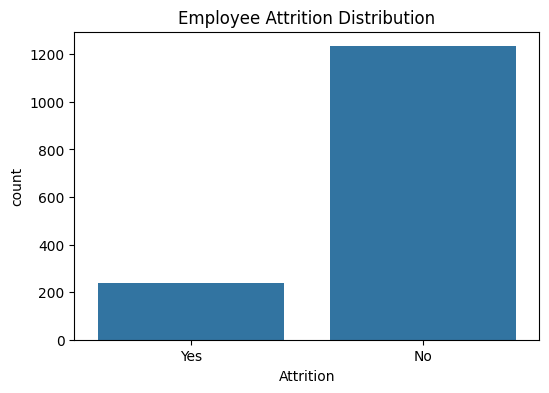

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=df["Attrition"])

plt.title("Employee Attrition Distribution")

plt.show()

In [ ]:
### Class inbalance
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0})

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
df["EmployeeCount"].value_counts()

,count
EmployeeCount,
1,1470


In [ ]:
df["Over18"].value_counts()

,count
Over18,
Y,1470


In [ ]:
df["StandardHours"].value_counts()

,count
StandardHours,
80,1470


Feature Selection / Feature Cleaning

In [ ]:
df["EmployeeCount"].value_counts()

df["Over18"].value_counts()

df["StandardHours"].value_counts()

,count
StandardHours,
80,1470


In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0})

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,


In [ ]:
df.select_dtypes(include="object").columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "BusinessTravel",
        "Department",
        "EducationField",
        "Gender",
        "JobRole",
        "MaritalStatus",
        "OverTime" ],
    drop_first=True)

In [ ]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

### MODELLEME

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [ ]:
df["Attrition"].unique()

array([nan])

In [ ]:
df["Attrition"] = df["Attrition"].replace({
    "Yes": 1,
    "No": 0})

In [ ]:
df["Attrition"].isnull().sum()

np.int64(1470)

In [ ]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [ ]:
# Attrition sütununda ne var kontrol edelim
df["Attrition"].unique()

array([nan])

In [ ]:
import pandas as pd

df = pd.read_csv(
    "WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0})

In [ ]:
df["Attrition"].unique()

array([1, 0])

In [ ]:
df["Attrition"].isnull().sum()

np.int64(0)

In [ ]:
df = df.drop(
    [
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours" ],
    axis=1,
    errors="ignore")

In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True)

In [ ]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [ ]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)

from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

import pandas as pd

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42)}

In [ ]:
results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({

        "Model": model_name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748
1,Decision Tree,0.768707,0.266667,0.255319,0.260870
2,Random Forest,0.840136,0.500000,0.085106,0.145455
3,Gradient Boosting,0.850340,0.588235,0.212766,0.312500
4,XGBoost,0.857143,0.666667,0.212766,0.322581


In [ ]:
from sklearn.metrics import confusion_matrix

best_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

cm

array([[192,  55],
       [ 18,  29]])

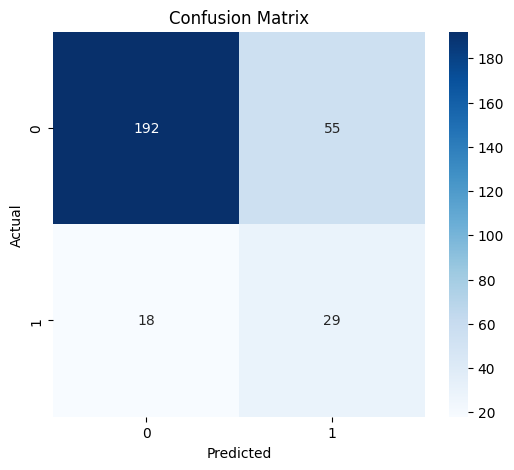

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows that the Logistic Regression model achieved balanced classification performance on the employee attrition dataset.

### Results
- 192 employees who stayed at the company were correctly classified.
- 29 employees who left the company were correctly identified.
- 55 employees were incorrectly predicted as likely to leave.
- 18 employees who actually left the company were missed by the model.

### Interpretation

In employee attrition prediction, minimizing false negatives is especially important because failing to identify employees at risk of leaving may result in talent loss for the company.

Although the model produced some false positives, it successfully identified a significant portion of employees likely to leave, making it useful for HR analytics and employee retention strategies.